# Healthcare Analytics for Doctor Visits

---

**Project Type:** Academic & Portfolio — Exploratory Data Analysis  
**Dataset:** Doctor Visits Survey (5,190 records)  
**Author:** Ritusmita Dutta  
**Date:** 2026-09-21  

---

## Project Overview

This notebook performs a complete exploratory data analysis (EDA) of a healthcare survey
dataset focused on doctor-visit frequency. The dataset contains demographic, health, insurance,
and chronic-condition variables for 5,190 survey respondents.

**The analysis is purely descriptive and exploratory.** No causal claims are made.
Patterns and associations are reported responsibly, with uncertainty and data limitations
documented throughout.

---

> **Ethical Notice:**  
> All findings are statistical patterns only. Correlation does not imply causation.
> These results should not be used for clinical or policy decisions without further
> rigorous analysis and domain expertise.

## 1. Analytical Objectives

This project investigates the following exploratory questions:

1. What is the distribution of doctor visits in this population?
2. What percentage of respondents report zero visits?
3. How does visit frequency vary across age groups?
4. Do respondents reporting illness show different visit counts than those reporting none?
5. What is the relationship between reduced-activity days and visit count?
6. How do limiting vs. non-limiting chronic conditions relate to utilization?
7. Does insurance type relate to visit patterns?
8. How do government-assisted groups compare with privately insured respondents?
9. Does income level appear associated with visit frequency?
10. Are there gender differences in visit frequency?
11. What characterizes zero-visit vs. high-utilizer respondents?
12. How is the self-rated health score associated with visit count?

> These are exploratory questions, not pre-determined hypotheses.

## 2. Dataset Description

| Property | Value |
|---|---|
| **Raw file** | `data/raw/doctor_visits_raw.csv` |
| **Processed file** | `data/processed/doctor_visits_clean.csv` |
| **Rows** | 5,190 |
| **Cleaned columns** | 26 (12 original + 14 engineered) |
| **Missing values** | 0 |

The dataset is consistent with the Doctor Visits dataset from Cameron & Trivedi (1986),
an Australian health survey. Country, year, and exact survey methodology are not
confirmed in the file itself — generalizations to specific populations are not made.

## 3. Data Dictionary

### Original Columns

| Column | Type | Meaning | Notes |
|---|---|---|---|
| `visits` | int | Doctor visits in the reference period | Target variable; zero-inflated |
| `gender` | str | Patient gender | 'female' / 'male' only |
| `age` | float | Age scaled (e.g. 0.19 = 19 yrs) | 12 discrete bands |
| `income` | float | Household income, normalized 0–1.5 | 79 rows = 0 (ambiguous) |
| `illness` | int | Self-reported illness count, past 2 weeks | 0–5 |
| `reduced` | int | Days of reduced activity, past 2 weeks | 14 = ceiling |
| `health` | int | Self-rated health score | 0–12; scale direction unknown |
| `private` | str | Has private insurance | 'yes'/'no' |
| `freepoor` | str | Govt free care (low-income) | 'yes'/'no' |
| `freerepat` | str | Govt free care (repatriated) | 'yes'/'no' |
| `nchronic` | str | Non-limiting chronic condition | 'yes'/'no' |
| `lchronic` | str | Limiting chronic condition | 'yes'/'no' |

### Engineered Columns

| Column | Meaning |
|---|---|
| `age_years` | `age × 100` — year-band label |
| `age_group` | '<=25' / '26-35' / '36-45' / '46-55' / '56-65' / '66+' |
| `income_zero_flag` | 1 if income == 0 |
| `income_group` | Low / Lower-Mid / Upper-Mid / High |
| `*_enc` | Binary 0/1 encodings of yes/no columns |
| `insurance_type` | Single category: Private / Free-Poor / Free-Repatriated / Uninsured |
| `chronic_status` | No Condition / Non-Limiting / Limiting |
| `visit_group` | 0 visits / 1-2 / 3-5 / 6+ |
| `reduced_at_ceiling` | 1 if reduced == 14 |

## 4. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.constrained_layout.use': False,
    'figure.facecolor': 'white',      
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': '#1f2933',
    'axes.labelcolor': '#1f2933',
    'xtick.color': '#1f2933',
    'ytick.color': '#1f2933',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'axes.labelsize': 11,
    'axes.labelpad': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'legend.frameon': True,
})

try:
    import matplotlib_inline.backend_inline
    matplotlib_inline.backend_inline.set_matplotlib_formats('png', **{'facecolor': 'white'})
except ImportError:
    pass

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)


def display_table(table, caption=None, hide_index=False):
    """Render an existing DataFrame with consistent portfolio-ready styling."""
    styler = table.style
    formatters = {}
    for column in table.columns:
        column_name = str(column).lower()
        if '%' in column_name or 'percentage' in column_name:
            continue
        if pd.api.types.is_numeric_dtype(table[column]):
            count_like = (
                pd.api.types.is_integer_dtype(table[column])
                or column_name.strip() in {'n', 'count', 'rows', 'columns', 'respondents'}
                or any(token in column_name for token in ['count', 'respondents'])
            )
            formatters[column] = '{:,.0f}' if count_like else '{:,.4f}'
    if formatters:
        styler = styler.format(formatters, na_rep='-')
    
    styler = styler.set_properties(**{
        'font-size': '10pt !important',
        'padding': '8px 12px !important',
        'vertical-align': 'middle !important',
        'font-family': 'segoe ui, helvetica, arial, sans-serif !important',
    })
    
    styler = styler.set_table_styles([
        {'selector': 'table', 'props': [('width', '100%'), ('border-collapse', 'collapse'), ('margin-top', '20px !important'), ('margin-bottom', '20px !important'), ('border', '1px solid #d5dde5 !important'), ('background-color', '#ffffff !important')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-weight', 'bold !important'), ('color', '#1f2933 !important'), ('background-color', '#ffffff !important'), ('text-align', 'left !important'), ('padding', '10px !important'), ('font-size', '12pt !important')]},
        {'selector': 'th', 'props': [('font-weight', 'bold !important'), ('color', '#ffffff !important'), ('background-color', '#16324f !important'), ('vertical-align', 'middle !important'), ('border', '1px solid #0f2438 !important'), ('padding', '8px 12px !important')]},
        {'selector': '.col_heading', 'props': [('background-color', '#16324f !important'), ('color', '#ffffff !important'), ('white-space', 'normal !important'), ('border', '1px solid #0f2438 !important')]},
        {'selector': '.row_heading', 'props': [('background-color', '#16324f !important'), ('color', '#ffffff !important'), ('text-align', 'left !important'), ('font-weight', '600 !important'), ('border', '1px solid #0f2438 !important')]},
        {'selector': '.index_name', 'props': [('background-color', '#16324f !important'), ('color', '#ffffff !important'), ('text-align', 'left !important'), ('border', '1px solid #0f2438 !important')]},
        {'selector': '.blank', 'props': [('background-color', '#16324f !important'), ('color', '#ffffff !important'), ('border', '1px solid #0f2438 !important')]},
        {'selector': 'td', 'props': [('border', '1px solid #d5dde5 !important'), ('padding', '8px 12px !important'), ('background-color', '#ffffff !important'), ('color', '#1f2933 !important')]},
        {'selector': '.data', 'props': [('background-color', '#ffffff !important'), ('color', '#1f2933 !important'), ('white-space', 'normal !important')]},
        {'selector': 'tbody tr:nth-child(even) .data', 'props': [('background-color', '#eef3f7 !important')]},
        {'selector': 'tbody tr:nth-child(even) td', 'props': [('background-color', '#eef3f7 !important')]},
        {'selector': 'tbody tr:nth-child(even) .row_heading', 'props': [('background-color', '#0f2438 !important')]},
    ], overwrite=False)
    
    numeric_columns = table.select_dtypes(include='number').columns.tolist()
    text_columns = [column for column in table.columns if column not in numeric_columns]
    
    header_alignments = {}
    if numeric_columns:
        styler = styler.set_properties(subset=numeric_columns, **{'text-align': 'right !important'})
        for col in numeric_columns:
            header_alignments[col] = [{'selector': 'th', 'props': [('text-align', 'right !important')]}]
    if text_columns:
        styler = styler.set_properties(subset=text_columns, **{'text-align': 'left !important'})
        for col in text_columns:
            header_alignments[col] = [{'selector': 'th', 'props': [('text-align', 'left !important')]}]
            
    if header_alignments:
        styler = styler.set_table_styles(header_alignments, overwrite=False)
        
    if caption:
        styler = styler.set_caption(caption)
    if hide_index:
        styler = styler.hide(axis='index')
    display(styler)


PROC_PATH = '../data/processed/doctor_visits_clean.csv'
RAW_PATH  = '../data/raw/doctor_visits_raw.csv'

runtime_summary = pd.DataFrame({
    'Component': ['Libraries', 'pandas', 'numpy'],
    'Status': ['Loaded', pd.__version__, np.__version__]
})
display_table(runtime_summary, caption='Runtime environment')


,Component,Status
0,Libraries,Loaded
1,pandas,3.0.5
2,numpy,2.5.1


## 5. Loading the Processed Dataset

We load the **cleaned** dataset produced in Phase 2.  
The raw file (`data/raw/doctor_visits_raw.csv`) remains unmodified.

In [2]:
df = pd.read_csv(PROC_PATH)

# Dataset overview
overview = pd.DataFrame({
    'Property': ['Rows', 'Columns', 'Missing Values'],
    'Value': [df.shape[0], df.shape[1], df.isnull().sum().sum()]
}).set_index('Property')
display_table(overview, caption='Processed dataset overview')
display_table(df.head(), caption='First five records', hide_index=True)


,Value
Property,
Rows,"5,190"
Columns,26
Missing Values,0


visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years,age_group,income_zero_flag,income_group,private_enc,freepoor_enc,freerepat_enc,nchronic_enc,lchronic_enc,gender_enc,insurance_type,chronic_status,visit_group,reduced_at_ceiling
1,female,0.1900,0.5500,1,4,1,yes,no,no,no,no,19,<=25,0,Upper-Mid(0.46-0.75),1,0,0,0,0,0,Private,No Condition,1-2 visits,0
1,female,0.1900,0.4500,1,2,1,yes,no,no,no,no,19,<=25,0,Lower-Mid(0.16-0.45),1,0,0,0,0,0,Private,No Condition,1-2 visits,0
1,male,0.1900,0.9000,3,0,0,no,no,no,no,no,19,<=25,0,High(0.76-1.50),0,0,0,0,0,1,Uninsured,No Condition,1-2 visits,0
1,male,0.1900,0.1500,1,0,0,no,no,no,no,no,19,<=25,0,Low(0-0.15),0,0,0,0,0,1,Uninsured,No Condition,1-2 visits,0
1,male,0.1900,0.4500,2,5,1,no,no,no,yes,no,19,<=25,0,Lower-Mid(0.16-0.45),0,0,0,1,0,1,Uninsured,Non-Limiting,1-2 visits,0


### 💡 Key Insight

> The processed dataset contains 5,190 rows, 26 columns, and no missing values. The analysis therefore proceeds from a complete processed table, while the documented limitations still apply to variable definitions and survey context.

## 6. Descriptive Statistics

This section summarises the shape, types, distributions, and key statistics
of every relevant column in the processed dataset.

In [3]:
# Column data types as a clean table
dtype_df = pd.DataFrame({
    'Column': df.dtypes.index,
    'Dtype': df.dtypes.astype(str).values
})
shape_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns'],
    'Value': [f'{df.shape[0]:,}', df.shape[1]]
}).set_index('Metric')
display_table(shape_summary, caption='Dataset dimensions')
display_table(dtype_df.set_index('Column'), caption='Column data types')


,Value
Metric,
Rows,"5,190"
Columns,26


,Dtype
Column,
visits,int64
gender,str
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,str
freepoor,str


In [4]:
num_cols = ['visits', 'age_years', 'income', 'illness', 'reduced', 'health']

summary = df[num_cols].agg(['count','min','max','mean','median','std']).T
summary.columns = ['Count','Min','Max','Mean','Median','Std Dev']
display_table(summary.round(4), caption='Numerical summary statistics')


,Count,Min,Max,Mean,Median,Std Dev
visits,"5,190",0.0000,9.0000,0.3017,0.0000,0.7981
age_years,"5,190",19.0000,72.0000,40.6385,32.0000,20.4782
income,"5,190",0.0000,1.5000,0.5832,0.5500,0.3689
illness,"5,190",0.0000,5.0000,1.4320,1.0000,1.3842
reduced,"5,190",0.0000,14.0000,0.8618,0.0000,2.8876
health,"5,190",0.0000,12.0000,1.2175,0.0000,2.1243


In [5]:
cat_cols = ['gender','private','freepoor','freerepat','nchronic','lchronic',
            'age_group','income_group','insurance_type','chronic_status','visit_group']

for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'Category': vc.index, 'Count': vc.values, 'Percentage': pct.values})
    tbl['Percentage'] = tbl['Percentage'].map(lambda value: f'{value:.1f}%')
    display_table(tbl.set_index('Category'), caption=f'{col} frequency table')


,Count,Percentage
Category,,
female,"2,702",52.1%
male,"2,488",47.9%


,Count,Percentage
Category,,
no,"2,892",55.7%
yes,"2,298",44.3%


,Count,Percentage
Category,,
no,"4,968",95.7%
yes,222,4.3%


,Count,Percentage
Category,,
no,"4,099",79.0%
yes,"1,091",21.0%


,Count,Percentage
Category,,
no,"3,098",59.7%
yes,"2,092",40.3%


...

,Count,Percentage
Category,,
<=25,"1,965",37.9%
66+,"1,137",21.9%
26-35,824,15.9%
56-65,589,11.3%
46-55,403,7.8%
36-45,272,5.2%


,Count,Percentage
Category,,
Lower-Mid(0.16-0.45),"2,057",39.6%
Upper-Mid(0.46-0.75),"1,363",26.3%
High(0.76-1.50),"1,327",25.6%
Low(0-0.15),443,8.5%


,Count,Percentage
Category,,
Private,"2,298",44.3%
Uninsured,"1,579",30.4%
Free-Repatriated,"1,091",21.0%
Free-Poor,222,4.3%


,Count,Percentage
Category,,
No Condition,"2,493",48.0%
Non-Limiting,"2,092",40.3%
Limiting,605,11.7%


,Count,Percentage
Category,,
0 visits,"4,141",79.8%
1-2 visits,956,18.4%
3-5 visits,63,1.2%
6+ visits,30,0.6%


In [6]:
orig_cols = ['visits','gender','age','income','illness','reduced','health',
             'private','freepoor','freerepat','nchronic','lchronic']
missing = df.isnull().sum()
n_dup = df.duplicated(subset=orig_cols).sum()

quality_summary = pd.DataFrame({
    'Check': ['Missing values (total)', f'Duplicate rows (on 12 original columns)'],
    'Result': [
        'None' if missing.sum() == 0 else str(missing.sum()),
        f'{n_dup} (expected — only 12 discrete-valued columns; no rows removed)'
    ]
}).set_index('Check')
display_table(quality_summary, caption='Data quality checks')


,Result
Check,
Missing values (total),None
Duplicate rows (on 12 original columns),1320 (expected — only 12 discrete-valued columns; no rows removed)


### 💡 Key Insight

> The quality checks show no missing values and 1,320 repeated attribute profiles across the original columns. These repeated profiles are retained because they can represent distinct respondents with the same recorded characteristics.

### 6.1 Visit Count Distribution

The `visits` column is the primary target variable.
It records the number of doctor consultations in the survey reference period.

In [7]:
vc = df['visits'].value_counts().sort_index()
pct = (vc / len(df) * 100).round(2)
tbl = pd.DataFrame({'Count': vc, 'Pct (%)': pct.map(lambda value: f'{value:.2f}%')})
tbl.index.name = 'Visits'
display_table(tbl, caption='Visit-count frequency table')

stats_tbl = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Max', 'Zero-visit respondents'],
    'Value': [
        f'{df.visits.mean():.4f}',
        f'{df.visits.median():.1f}',
        f'{df.visits.std():.4f}',
        str(df.visits.max()),
        f'{(df.visits==0).sum():,} ({(df.visits==0).mean()*100:.2f}%)'
    ]
}).set_index('Metric')
display_table(stats_tbl, caption='Visit-count summary')


,Count,Pct (%)
Visits,,
0,"4,141",79.79%
1,782,15.07%
2,174,3.35%
3,30,0.58%
4,24,0.46%
5,9,0.17%
6,12,0.23%
7,12,0.23%
8,5,0.10%


,Value
Metric,
Mean,0.3017
Median,0.0
Std Dev,0.7981
Max,9
Zero-visit respondents,"4,141 (79.79%)"


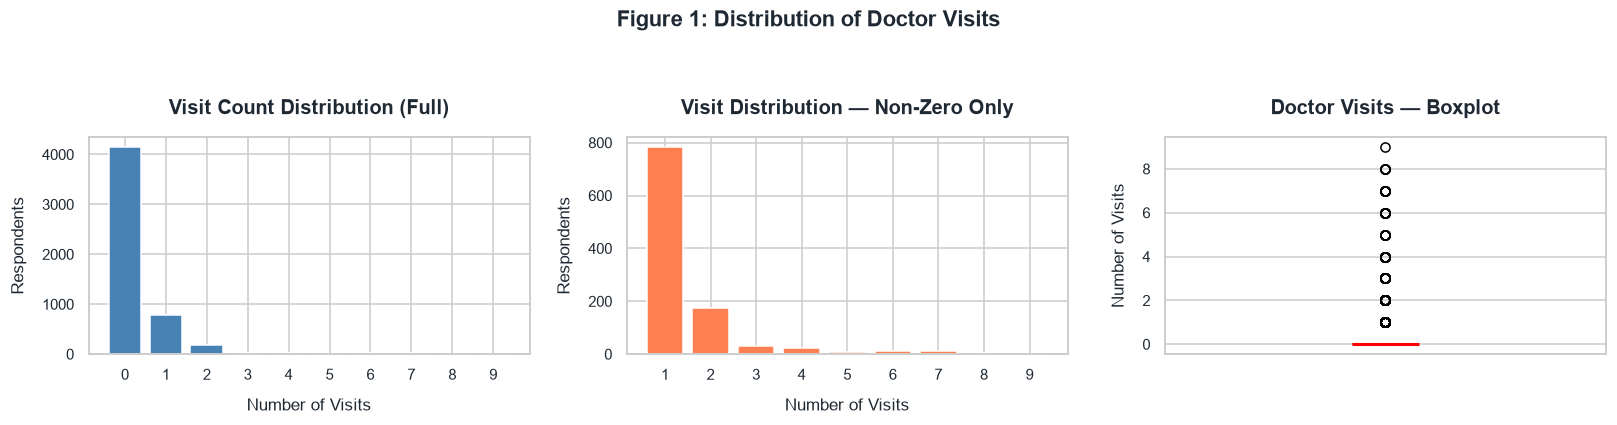

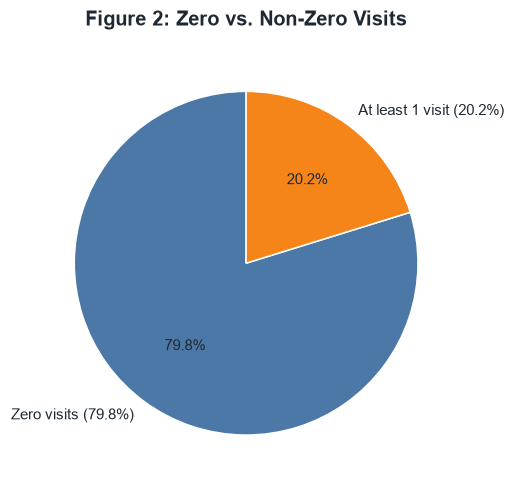

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full histogram
vc_vals = df['visits'].value_counts().sort_index()
axes[0].bar(vc_vals.index.astype(str), vc_vals.values, color='steelblue', edgecolor='white')
axes[0].set_title('Visit Count Distribution (Full)')
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Respondents')

# Non-zero only
nz = df[df['visits'] > 0]['visits'].value_counts().sort_index()
axes[1].bar(nz.index.astype(str), nz.values, color='coral', edgecolor='white')
axes[1].set_title('Visit Distribution — Non-Zero Only')
axes[1].set_xlabel('Number of Visits')
axes[1].set_ylabel('Respondents')

# Boxplot
axes[2].boxplot(df['visits'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Doctor Visits — Boxplot')
axes[2].set_ylabel('Number of Visits')
axes[2].set_xticks([])

plt.suptitle('Figure 1: Distribution of Doctor Visits', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95], pad=1.5)
plt.savefig('../data/processed/fig1_visits_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

# Zero vs Non-zero pie
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.pie(
    [(df['visits']==0).sum(), (df['visits']>0).sum()],
    labels=['Zero visits (79.8%)', 'At least 1 visit (20.2%)'],
    colors=['#4c78a8', '#f58518'], startangle=90,
    autopct='%1.1f%%', textprops={'fontsize': 10}
)
ax2.set_title('Figure 2: Zero vs. Non-Zero Visits')
plt.tight_layout(rect=[0, 0, 1, 0.95], pad=1.5)
plt.savefig('../data/processed/fig2_zero_vs_nonzero.png', dpi=110, bbox_inches='tight')
plt.show()

### 💡 Key Insight

> Doctor visits are strongly concentrated at zero: 4,141 respondents, or 79.79%, reported no visits. The distribution is therefore zero-inflated and right-skewed, so the mean should be interpreted alongside the median and the full distribution.

### 6.2 Age Group Distribution

`age` is stored as a scaled decimal (0.19–0.72). `age_years` = `age × 100` gives
12 discrete year-bands. `age_group` bins them into six analysis-friendly categories.

,Count,Pct (%)
Age Group,,
<=25,"1,965",37.9%
26-35,824,15.9%
36-45,272,5.2%
46-55,403,7.8%
56-65,589,11.3%
66+,"1,137",21.9%


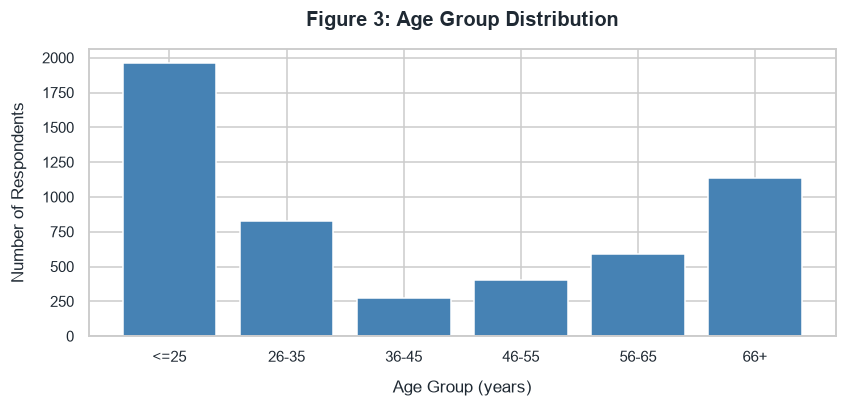

In [9]:
age_order = ['<=25', '26-35', '36-45', '46-55', '56-65', '66+']
ag = df['age_group'].value_counts().reindex(age_order)
pct_ag = (ag / len(df) * 100).round(1)
ag_tbl = pd.DataFrame({'Count': ag, 'Pct (%)': pct_ag.map(lambda value: f'{value:.1f}%')})
ag_tbl.index.name = 'Age Group'
display_table(ag_tbl, caption='Age-group frequency table')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ag.index, ag.values, color='steelblue', edgecolor='white')
ax.set_title('Figure 3: Age Group Distribution')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Number of Respondents')
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig3_age_distribution.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The sample is concentrated in the youngest and oldest grouped categories: respondents aged <=25 account for 37.9%, while those aged 66+ account for 21.9%. These are descriptive sample proportions, not population estimates.

### 6.3 Income Distribution

`income` is a normalized value (0.00–1.50) with 14 discrete levels.
79 respondents have `income = 0` — flagged separately as potentially ambiguous.

,Count,Pct (%)
Income Group,,
Low(0-0.15),443,8.5%
Lower-Mid(0.16-0.45),"2,057",39.6%
Upper-Mid(0.46-0.75),"1,363",26.3%
High(0.76-1.50),"1,327",25.6%


,Value,Interpretation
Metric,,
Income = 0 respondents,79,Ambiguous; not imputed


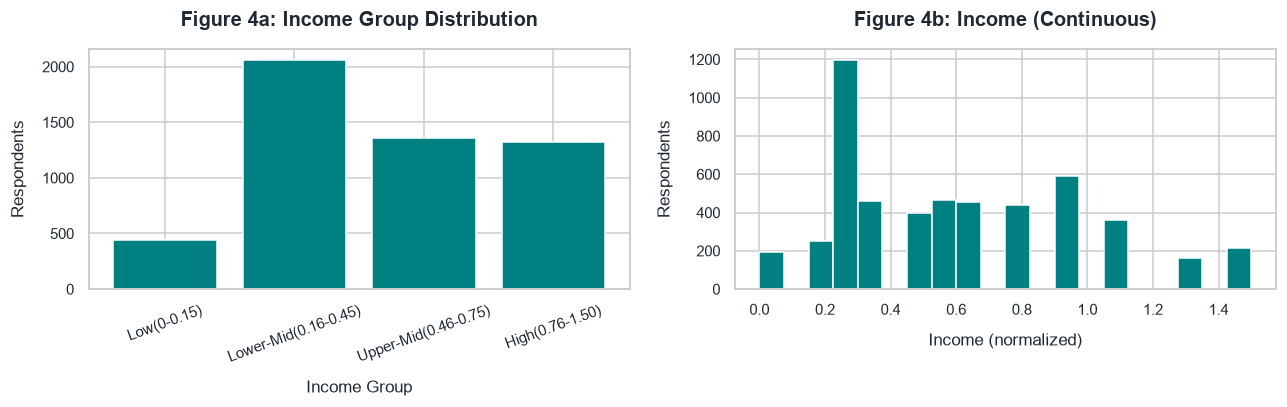

In [10]:
ig_order = ['Low(0-0.15)', 'Lower-Mid(0.16-0.45)', 'Upper-Mid(0.46-0.75)', 'High(0.76-1.50)']
ig = df['income_group'].value_counts().reindex(ig_order)
ig_tbl = pd.DataFrame({'Count': ig, 'Pct (%)': (ig/len(df)*100).round(1).map(lambda value: f'{value:.1f}%')})
ig_tbl.index.name = 'Income Group'
display_table(ig_tbl, caption='Income-group frequency table')

income_note = pd.DataFrame({
    'Metric': ['Income = 0 respondents'],
    'Value': [df.income_zero_flag.sum()],
    'Interpretation': ['Ambiguous; not imputed']
}).set_index('Metric')
display_table(income_note, caption='Income coding note')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(ig.index, ig.values, color='teal', edgecolor='white')
axes[0].set_title('Figure 4a: Income Group Distribution')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Respondents')
axes[0].tick_params(axis='x', rotation=20)

axes[1].hist(df['income'], bins=20, color='teal', edgecolor='white')
axes[1].set_title('Figure 4b: Income (Continuous)')
axes[1].set_xlabel('Income (normalized)')
axes[1].set_ylabel('Respondents')

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig4_income_distribution.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The largest income group is Lower-Mid at 39.6%, followed by Upper-Mid at 26.3% and High at 25.6%. The 79 income=0 records remain ambiguous and were not imputed.

### 6.4 Health Variable Distributions

- **illness**: self-reported count of illnesses in the past 2 weeks (0–5)
- **reduced**: days of reduced activity (0–14; 14 is a censoring ceiling)
- **health**: self-rated health score (0–12; scale direction not documented)

,Mean,Median,Std Dev,Max
Variable,,,,
illness,1.4320,1.0000,1.3840,5
reduced,0.8620,0.0000,2.8880,14
health,1.2180,0.0000,2.1240,12


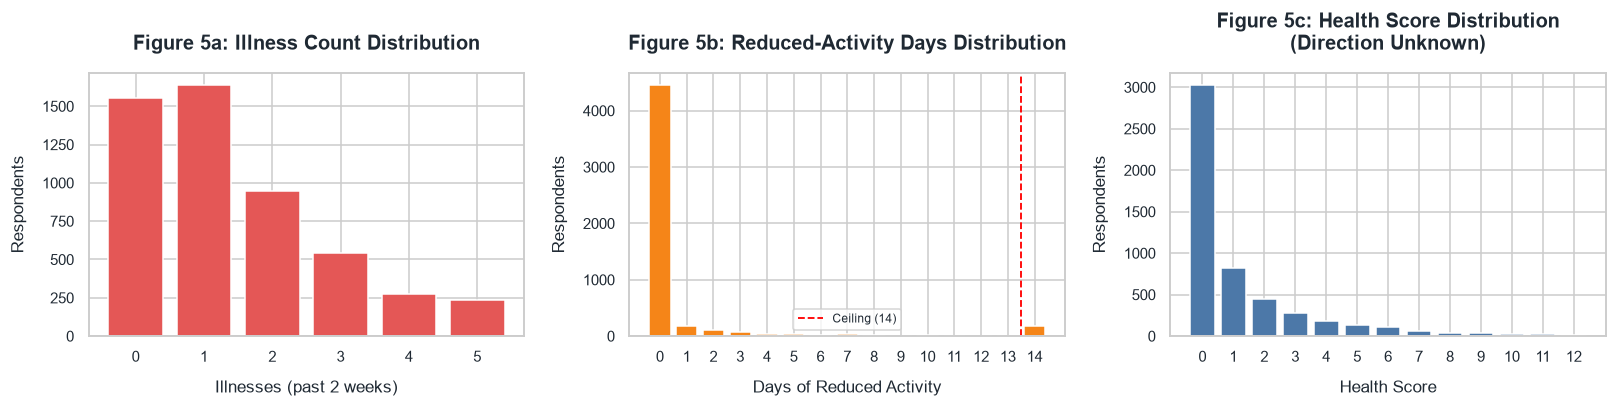

In [11]:
# Summary statistics table first
health_summary = pd.DataFrame({
    'Variable': ['illness', 'reduced', 'health'],
    'Mean': [df['illness'].mean(), df['reduced'].mean(), df['health'].mean()],
    'Median': [df['illness'].median(), df['reduced'].median(), df['health'].median()],
    'Std Dev': [df['illness'].std(), df['reduced'].std(), df['health'].std()],
    'Max': [df['illness'].max(), df['reduced'].max(), df['health'].max()]
}).set_index('Variable').round(3)
display_table(health_summary, caption='Health-variable summary statistics')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Illness
ill_vc = df['illness'].value_counts().sort_index()
axes[0].bar(ill_vc.index.astype(str), ill_vc.values, color='#e45756', edgecolor='white')
axes[0].set_title('Figure 5a: Illness Count Distribution')
axes[0].set_xlabel('Illnesses (past 2 weeks)')
axes[0].set_ylabel('Respondents')

# Reduced
red_vc = df['reduced'].value_counts().sort_index()
axes[1].bar(red_vc.index.astype(str), red_vc.values, color='#f58518', edgecolor='white')
axes[1].set_title('Figure 5b: Reduced-Activity Days Distribution')
axes[1].set_xlabel('Days of Reduced Activity')
axes[1].set_ylabel('Respondents')
axes[1].axvline(x=13.5, color='red', linestyle='--', linewidth=1.2, label='Ceiling (14)')
axes[1].legend(fontsize=8)

# Health
hlt_vc = df['health'].value_counts().sort_index()
axes[2].bar(hlt_vc.index.astype(str), hlt_vc.values, color='#4c78a8', edgecolor='white')
axes[2].set_title('Figure 5c: Health Score Distribution\n(Direction Unknown)')
axes[2].set_xlabel('Health Score')
axes[2].set_ylabel('Respondents')

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig5_health_vars.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The health-burden variables have different distributions: illness has a mean of 1.432, reduced activity has a mean of 0.862 days, and the health score has a mean of 1.218. The health score direction is undocumented, so its values should not receive a directional medical interpretation.

## 7. Feature Validation

We verify each engineered feature is logically consistent with the raw source columns.

In [12]:
checks = []

# age_years consistency
assert (df['age_years'] == (df['age'] * 100).round(0).astype(int)).all(), 'age_years mismatch'
checks.append({'Feature': 'age_years', 'Result': f'min={df.age_years.min()}, max={df.age_years.max()}', 'Status': 'PASS'})

# income_zero_flag consistency
assert ((df['income']==0) == (df['income_zero_flag']==1)).all(), 'income_zero_flag mismatch'
checks.append({'Feature': 'income_zero_flag', 'Result': f'{df.income_zero_flag.sum()} rows flagged', 'Status': 'PASS'})

# reduced_at_ceiling consistency
assert ((df['reduced']==14) == (df['reduced_at_ceiling']==1)).all(), 'ceiling flag mismatch'
checks.append({'Feature': 'reduced_at_ceiling', 'Result': f'{df.reduced_at_ceiling.sum()} rows flagged', 'Status': 'PASS'})

# insurance_type exclusivity
overlap = (df[['private_enc','freepoor_enc','freerepat_enc']].sum(axis=1) > 1).sum()
assert overlap == 0, 'Insurance overlap found'
checks.append({'Feature': 'insurance_type exclusivity', 'Result': '0 overlaps', 'Status': 'PASS'})

# Binary encodings
for col in ['private','freepoor','freerepat','nchronic','lchronic']:
    enc = df[col + '_enc']
    expected = df[col].map({'yes': 1, 'no': 0})
    assert (enc == expected).all(), f'{col}_enc mismatch'
    checks.append({'Feature': f'{col}_enc', 'Result': f'0={( enc==0).sum()}, 1={( enc==1).sum()}', 'Status': 'PASS'})

# chronic_status
assert set(df['chronic_status'].unique()) == {'No Condition', 'Non-Limiting', 'Limiting'}
checks.append({'Feature': 'chronic_status', 'Result': str(sorted(df.chronic_status.unique())), 'Status': 'PASS'})

# visit_group
assert set(df['visit_group'].unique()) == {'0 visits','1-2 visits','3-5 visits','6+ visits'}
checks.append({'Feature': 'visit_group', 'Result': str(sorted(df.visit_group.unique())), 'Status': 'PASS'})

val_df = pd.DataFrame(checks).set_index('Feature')
display_table(val_df, caption='Engineered-feature validation checks')


,Result,Status
Feature,,
age_years,"min=19, max=72",PASS
income_zero_flag,79 rows flagged,PASS
reduced_at_ceiling,188 rows flagged,PASS
insurance_type exclusivity,0 overlaps,PASS
private_enc,"0=2892, 1=2298",PASS
freepoor_enc,"0=4968, 1=222",PASS
freerepat_enc,"0=4099, 1=1091",PASS
nchronic_enc,"0=3098, 1=2092",PASS
lchronic_enc,"0=4585, 1=605",PASS


### 💡 Key Insight

> All engineered-feature validation checks pass, including binary encodings, insurance exclusivity, chronic-status categories, and visit groups. This supports using the processed features for the descriptive comparisons that follow.

## 8. Analytical Questions

Each question below uses actual calculations from the processed dataset.
All results are observational — no causal claims are made.

### Q1. What is the distribution of doctor visits?

The `visits` variable records the number of doctor consultations per respondent
in the survey reference period. It is an integer count and is expected to be
right-skewed (most people visit rarely or not at all).

In [13]:
desc = df['visits'].describe().round(4)
desc.index = ['Count', 'Mean', 'Std Dev', 'Min', '25th Pct', 'Median (50th)', '75th Pct', 'Max']
desc_df = desc.to_frame(name='Value')
desc_df.index.name = 'Statistic'
display_table(desc_df, caption='Doctor-visit descriptive statistics')

skew_kurt = pd.DataFrame({
    'Metric': ['Skewness', 'Kurtosis'],
    'Value': [f'{df.visits.skew():.4f}', f'{df.visits.kurt():.4f}'],
    'Interpretation': [
        'High positive skewness — strongly right-skewed distribution',
        'Excess kurtosis — heavy-tailed (driven by zero-inflation)'
    ]
}).set_index('Metric')
display_table(skew_kurt, caption='Distribution-shape statistics')


,Value
Statistic,
Count,"5,190.0000"
Mean,0.3017
Std Dev,0.7981
Min,0.0000
25th Pct,0.0000
Median (50th),0.0000
75th Pct,0.0000
Max,9.0000


,Value,Interpretation
Metric,,
Skewness,4.7426,High positive skewness — strongly right-skewed distribution
Kurtosis,31.3389,Excess kurtosis — heavy-tailed (driven by zero-inflation)


### 💡 Key Insight

> Visit counts are strongly right-skewed: the mean is 0.3017, the median is 0, and the maximum is 9. The median describes the typical zero-visit respondent more directly, while the mean reflects the non-zero tail.

### Q2. What percentage of respondents report zero visits?

Zero-visit respondents dominate this dataset. Understanding their prevalence
is essential before interpreting any group-level averages.

,Count,Pct (%)
Group,,
Zero visits,"4,141",79.79%
At least 1 visit,"1,049",20.21%
At least 3 visits (high utilizers),93,1.79%


,Detail
Metric,
Interpretive note,The high zero proportion pulls group means down; medians = 0 for most subgroups.


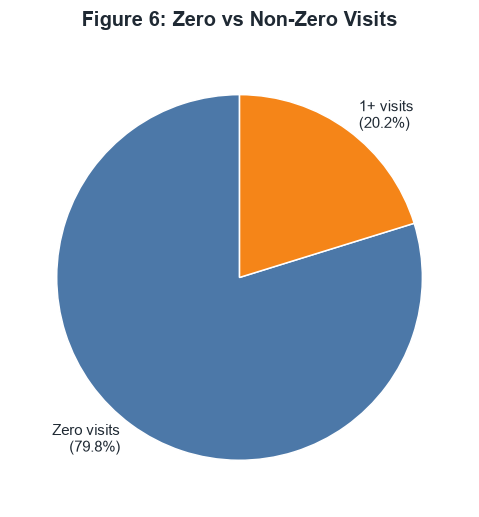

In [14]:
n_zero = (df['visits'] == 0).sum()
n_total = len(df)
pct_zero = n_zero / n_total * 100

zero_summary = pd.DataFrame({
    'Group': ['Zero visits', 'At least 1 visit', 'At least 3 visits (high utilizers)'],
    'Count': [n_zero, n_total - n_zero, (df.visits >= 3).sum()],
    'Pct (%)': [
        f'{pct_zero:.2f}%',
        f'{100 - pct_zero:.2f}%',
        f'{(df.visits >= 3).mean()*100:.2f}%'
    ]
}).set_index('Group')
display_table(zero_summary, caption='Zero-visit and high-utilizer summary')

audit_note = pd.DataFrame({
    'Metric': ['Interpretive note'],
    'Detail': ['The high zero proportion pulls group means down; medians = 0 for most subgroups.']
}).set_index('Metric')
display_table(audit_note, caption='Interpretive note')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [n_zero, n_total - n_zero],
    labels=[f'Zero visits\n({pct_zero:.1f}%)', f'1+ visits\n({100-pct_zero:.1f}%)'],
    colors=['#4c78a8', '#f58518'],
    startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title('Figure 6: Zero vs Non-Zero Visits')
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig6_zero_visits_pie.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Zero visits are the dominant outcome at 79.79%, while 1.79% of respondents reported at least three visits. This imbalance is important when comparing subgroup means and medians.

### Q3. How does average visit count differ across age groups?

Age is encoded in 12 discrete bands (19–72 years). We group into six categories
and compare mean visit counts. All medians are 0 due to zero-inflation, so
means are reported alongside counts.

,Count,Mean Visits,Median,Std Dev
Age Group,,,,
<=25,"1,965",0.2056,0.0000,0.6134
26-35,824,0.2524,0.0000,0.7274
36-45,272,0.2794,0.0000,0.7938
46-55,403,0.3499,0.0000,0.9380
56-65,589,0.3752,0.0000,0.8998
66+,"1,137",0.4538,0.0000,0.9750


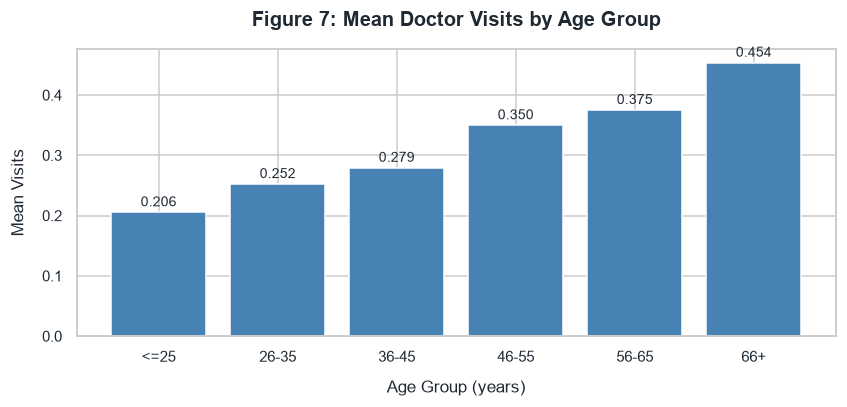

,Detail
Metric,
Interpretive note,Mean visits increase gradually with age; all medians = 0 due to zero-inflation. Differences are driven by the non-zero tail. No causal interpretation is made.


In [15]:
age_order = ['<=25', '26-35', '36-45', '46-55', '56-65', '66+']
ag = df.groupby('age_group')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(age_order).round(4)
ag.columns = ['Count', 'Mean Visits', 'Median', 'Std Dev']
ag.index.name = 'Age Group'
display_table(ag, caption='Mean visits by age group')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ag.index, ag['Mean Visits'], color='steelblue', edgecolor='white')
ax.set_title('Figure 7: Mean Doctor Visits by Age Group')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Mean Visits')
for i, (idx, row) in enumerate(ag.iterrows()):
    ax.text(i, row['Mean Visits'] + 0.005, f'{row["Mean Visits"]:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig7_age_visits.png', dpi=110, bbox_inches='tight')
plt.show()

age_note = pd.DataFrame({
    'Metric': ['Interpretive note'],
    'Detail': ['Mean visits increase gradually with age; all medians = 0 due to zero-inflation. Differences are driven by the non-zero tail. No causal interpretation is made.']
}).set_index('Metric')
display_table(age_note, caption='Interpretive note')


### 💡 Key Insight

> Mean visits increase across the displayed age groups from 0.2056 for respondents aged <=25 to 0.4538 for respondents aged 66+. This is an observed group pattern and does not establish an age effect.

### Q4. Do respondents reporting illness have different visit counts?

We compare respondents with at least one self-reported illness (past 2 weeks)
against those with none, and also examine visit counts by illness count (0–5).

,Count,Mean Visits,Median,Std Dev
Illness Group,,,,
No illness (0),"1,554",0.0785,0.0000,0.3153
Any illness (1+),"3,636",0.3971,0.0000,0.9146


,Count,Mean Visits
Illness Count,,
0,"1,554",0.0785
1,"1,638",0.2955
2,946,0.4038
3,542,0.4207
4,274,0.5766
5,236,0.8136


,Comparison,H Statistic,p-value,Significance
Test,,,,
Kruskal-Wallis,Visits across illness counts (0–5),366.0393,6.16e-77,Statistically significant (p < 0.001)


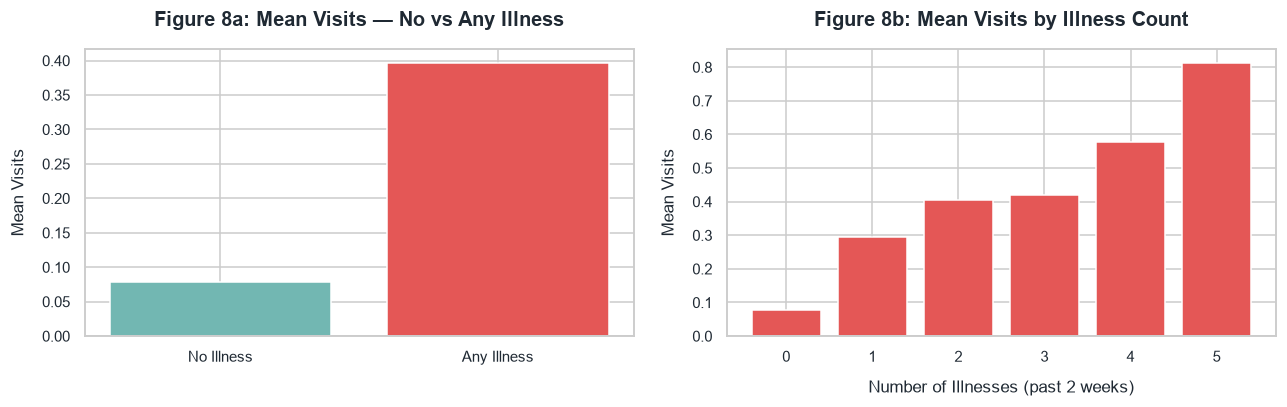

In [16]:
df['any_illness'] = (df['illness'] > 0).astype(int)
grp = df.groupby('any_illness')['visits'].agg(count='count', mean='mean', median='median', std='std')
grp.index = ['No illness (0)', 'Any illness (1+)']
grp.columns = ['Count', 'Mean Visits', 'Median', 'Std Dev']
grp.index.name = 'Illness Group'
display_table(grp.round(4), caption='Visits by illness group')

by_count = df.groupby('illness')['visits'].agg(count='count', mean='mean').round(4)
by_count.columns = ['Count', 'Mean Visits']
by_count.index.name = 'Illness Count'
display_table(by_count, caption='Visits by illness count')

# Kruskal-Wallis test
groups = [df[df['illness']==i]['visits'].values for i in range(6)]
kw_stat, kw_p = stats.kruskal(*groups)
kw_df = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'Comparison': ['Visits across illness counts (0–5)'],
    'H Statistic': [f'{kw_stat:.4f}'],
    'p-value': [f'{kw_p:.2e}'],
    'Significance': ['Statistically significant (p < 0.001)']
}).set_index('Test')
display_table(kw_df, caption='Illness-count statistical test')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Illness', 'Any Illness'], grp['Mean Visits'].values, color=['#72b7b2','#e45756'], edgecolor='white')
axes[0].set_title('Figure 8a: Mean Visits — No vs Any Illness')
axes[0].set_ylabel('Mean Visits')

axes[1].bar(by_count.index.astype(str), by_count['Mean Visits'], color='#e45756', edgecolor='white')
axes[1].set_title('Figure 8b: Mean Visits by Illness Count')
axes[1].set_xlabel('Number of Illnesses (past 2 weeks)')
axes[1].set_ylabel('Mean Visits')

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig8_illness_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Respondents reporting any illness had a higher mean visit count than those reporting none, 0.3971 versus 0.0785. The Kruskal-Wallis result also indicates differences across illness-count groups; these findings are associative, not causal.

### Q5. What is the relationship between reduced-activity days and visits?

`reduced` records days of reduced activity in the past 2 weeks (0–14).
The value 14 is a censoring ceiling. We use Spearman correlation
(appropriate for non-normal, right-skewed data).

,Variables,rho,p-value,Strength
Test,,,,
Spearman Correlation,reduced vs visits,0.3356,8.45e-137,Moderate positive monotonic association


,Count,Mean Visits,Median
Reduced Activity Tier,,,
0 days,"4,454",0.1839,0.0000
1-3 days,359,0.5738,0.0000
4-7 days,140,1.0857,1.0000
8-14 days,237,1.6414,1.0000


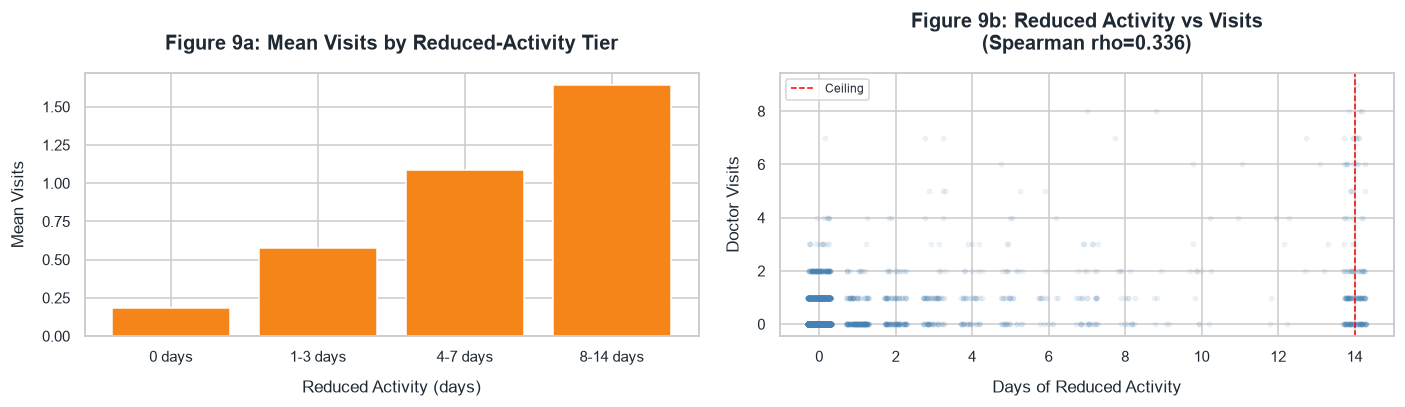

In [17]:
rho, pval = stats.spearmanr(df['reduced'], df['visits'])
spearman_df = pd.DataFrame({
    'Test': ['Spearman Correlation'],
    'Variables': ['reduced vs visits'],
    'rho': [f'{rho:.4f}'],
    'p-value': [f'{pval:.2e}'],
    'Strength': ['Moderate positive monotonic association']
}).set_index('Test')
display_table(spearman_df, caption='Reduced activity correlation')

df['reduced_tier'] = pd.cut(df['reduced'], bins=[-1, 0, 3, 7, 14],
                             labels=['0 days', '1-3 days', '4-7 days', '8-14 days'])
rt = df.groupby('reduced_tier')['visits'].agg(count='count', mean='mean', median='median').round(4)
rt.columns = ['Count', 'Mean Visits', 'Median']
rt.index.name = 'Reduced Activity Tier'
display_table(rt, caption='Visits by reduced-activity tier')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(rt.index, rt['Mean Visits'], color='#f58518', edgecolor='white')
axes[0].set_title('Figure 9a: Mean Visits by Reduced-Activity Tier')
axes[0].set_xlabel('Reduced Activity (days)')
axes[0].set_ylabel('Mean Visits')

# Scatter (jittered)
jitter = np.random.RandomState(42).uniform(-0.3, 0.3, len(df))
axes[1].scatter(df['reduced'] + jitter, df['visits'],
                alpha=0.08, s=8, color='steelblue')
axes[1].set_title(f'Figure 9b: Reduced Activity vs Visits\n(Spearman rho={rho:.3f})')
axes[1].set_xlabel('Days of Reduced Activity')
axes[1].set_ylabel('Doctor Visits')
axes[1].axvline(14, color='red', linestyle='--', linewidth=1, label='Ceiling')
axes[1].legend(fontsize=8)

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig9_reduced_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Reduced activity shows a moderate positive monotonic association with visits (Spearman rho = 0.3356). Mean visits rise from 0.1839 for 0 days to 1.6414 for 8–14 days, while the value 14 remains a documented ceiling.

### Q6. How do visit counts differ by chronic condition status?

Chronic status has three ordered levels:
- **No Condition** — neither nchronic nor lchronic
- **Non-Limiting** — non-limiting chronic condition only
- **Limiting** — limiting chronic condition (implies functional impact)

,Count,Mean Visits,Median,Std Dev
Chronic Status,,,,
No Condition,"2,493",0.1917,0.0000,0.6208
Non-Limiting,"2,092",0.3456,0.0000,0.8162
Limiting,605,0.6033,0.0000,1.1952


,Comparison,H Statistic,p-value,Note
Test,,,,
Kruskal-Wallis,Visits across chronic_status (3 groups),170.5948,9.03e-38,Non-parametric; appropriate for non-normal count data


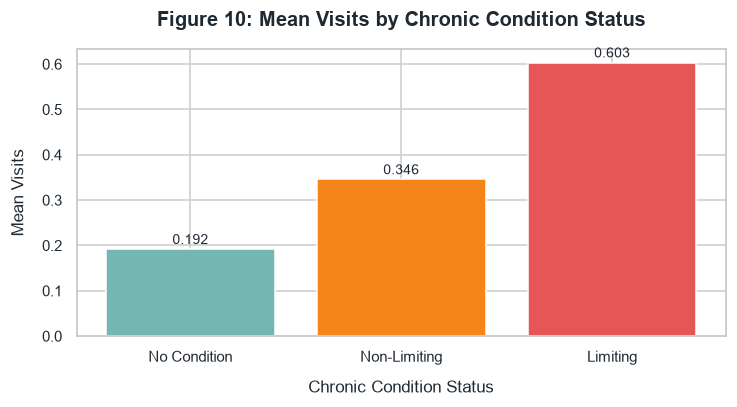

In [18]:
corder = ['No Condition', 'Non-Limiting', 'Limiting']
cs = df.groupby('chronic_status')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(corder).round(4)
cs.columns = ['Count', 'Mean Visits', 'Median', 'Std Dev']
cs.index.name = 'Chronic Status'
display_table(cs, caption='Visits by chronic-condition status')

# Kruskal-Wallis
grp_nc, grp_nl, grp_lm = (
    df[df['chronic_status']==g]['visits'] for g in corder
)
kw_h, kw_p = stats.kruskal(grp_nc, grp_nl, grp_lm)
kw_chronic = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'Comparison': ['Visits across chronic_status (3 groups)'],
    'H Statistic': [f'{kw_h:.4f}'],
    'p-value': [f'{kw_p:.2e}'],
    'Note': ['Non-parametric; appropriate for non-normal count data']
}).set_index('Test')
display_table(kw_chronic, caption='Chronic-status statistical test')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(corder, cs['Mean Visits'], color=['#72b7b2','#f58518','#e45756'], edgecolor='white')
ax.set_title('Figure 10: Mean Visits by Chronic Condition Status')
ax.set_xlabel('Chronic Condition Status')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, cs['Mean Visits']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig10_chronic_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Mean visits are highest for the Limiting chronic-status group at 0.6033, compared with 0.3456 for Non-Limiting and 0.1917 for No Condition. The group differences are descriptive associations within this dataset.

### Q7. How do visit counts differ by insurance type?

Insurance type is a mutually exclusive four-category variable derived from the
three original insurance columns (`private`, `freepoor`, `freerepat`).

,Count,Mean Visits,Median,Std Dev
Insurance Type,,,,
Private,"2,298",0.2946,0.0000,0.7722
Free-Poor,222,0.1577,0.0000,0.6974
Free-Repatriated,"1,091",0.4665,0.0000,0.9605
Uninsured,"1,579",0.2185,0.0000,0.7020


,Comparison,H Statistic,p-value,Significance
Test,,,,
Kruskal-Wallis,Visits across insurance_type (4 groups),138.0629,9.89e-30,Statistically significant (p < 0.001)


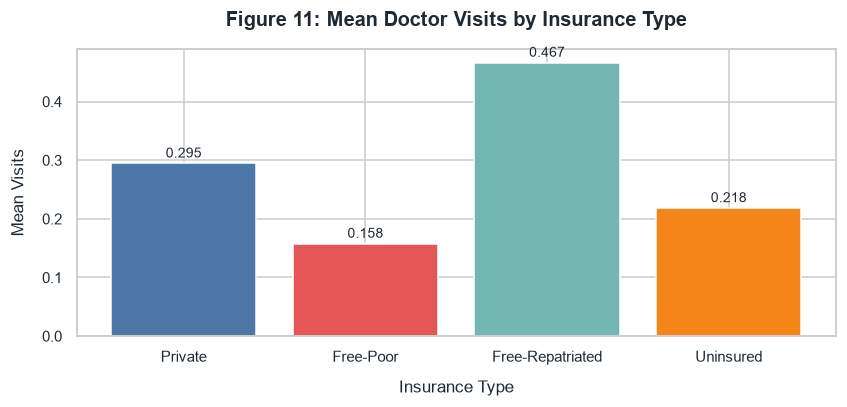

In [19]:
ins_order = ['Private', 'Free-Poor', 'Free-Repatriated', 'Uninsured']
ins = df.groupby('insurance_type')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).reindex(ins_order).round(4)
ins.columns = ['Count', 'Mean Visits', 'Median', 'Std Dev']
ins.index.name = 'Insurance Type'
display_table(ins, caption='Visits by insurance type')

kw_h, kw_p = stats.kruskal(*[df[df['insurance_type']==t]['visits'] for t in ins_order])
kw_ins = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'Comparison': ['Visits across insurance_type (4 groups)'],
    'H Statistic': [f'{kw_h:.4f}'],
    'p-value': [f'{kw_p:.2e}'],
    'Significance': ['Statistically significant (p < 0.001)']
}).set_index('Test')
display_table(kw_ins, caption='Insurance-type statistical test')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4c78a8', '#e45756', '#72b7b2', '#f58518']
bars = ax.bar(ins_order, ins['Mean Visits'], color=colors, edgecolor='white')
ax.set_title('Figure 11: Mean Doctor Visits by Insurance Type')
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, ins['Mean Visits']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig11_insurance_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Free-Repatriated respondents have the highest displayed mean visits at 0.4665, followed by Private at 0.2946, Uninsured at 0.2185, and Free-Poor at 0.1577. These differences should not be interpreted as effects of insurance status.

### Q8. How do government-assisted groups compare with privately insured respondents?

We pool Free-Poor and Free-Repatriated respondents into a government-assisted group
and compare their visit counts against privately insured respondents using a
non-parametric Mann-Whitney U test.

,n,Mean Visits,Median
Group,,,
Govt-Assisted (Free-Poor + Repatriated),"1,313",0.4143,0.0
Private,"2,298",0.2946,0.0


,Comparison,U Statistic,p-value,Note
Test,,,,
Mann-Whitney U,Govt-Assisted vs Private,1625202,1.26e-07,Two-sided; no assumption of equal variances


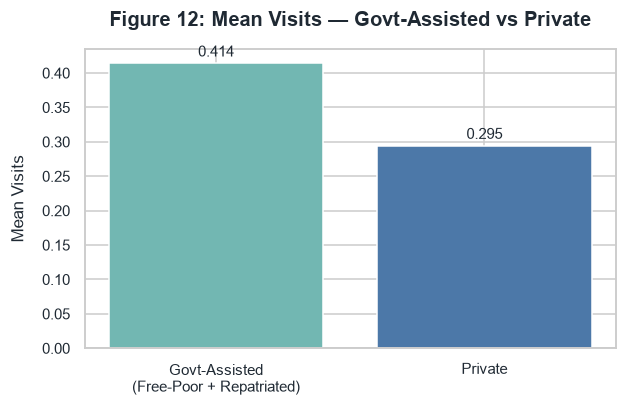

In [20]:
govt = df[df['insurance_type'].isin(['Free-Poor', 'Free-Repatriated'])]['visits']
priv = df[df['insurance_type'] == 'Private']['visits']

mw_stat, mw_p = stats.mannwhitneyu(govt, priv, alternative='two-sided')

grp_comparison = pd.DataFrame({
    'Group': ['Govt-Assisted (Free-Poor + Repatriated)', 'Private'],
    'n': [len(govt), len(priv)],
    'Mean Visits': [f'{govt.mean():.4f}', f'{priv.mean():.4f}'],
    'Median': [f'{govt.median():.1f}', f'{priv.median():.1f}']
}).set_index('Group')
display_table(grp_comparison, caption='Government-assisted versus private')

mw_df = pd.DataFrame({
    'Test': ['Mann-Whitney U'],
    'Comparison': ['Govt-Assisted vs Private'],
    'U Statistic': [f'{mw_stat:.0f}'],
    'p-value': [f'{mw_p:.2e}'],
    'Note': ['Two-sided; no assumption of equal variances']
}).set_index('Test')
display_table(mw_df, caption='Government-assisted versus private statistical test')

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Govt-Assisted\n(Free-Poor + Repatriated)', 'Private']
means  = [govt.mean(), priv.mean()]
bars = ax.bar(labels, means, color=['#72b7b2', '#4c78a8'], edgecolor='white')
ax.set_title('Figure 12: Mean Visits — Govt-Assisted vs Private')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig12_govt_vs_private.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The government-assisted group has a higher mean visit count than the Private group, 0.4143 versus 0.2946, and the displayed Mann-Whitney test is statistically significant. The comparison remains observational and may reflect differences in respondent characteristics.

### Q9. Does income level appear associated with visit frequency?

`income` is a normalized value (0.00–1.50). We examine both the continuous
Spearman correlation and the group-level mean visits by income tier.

,Variables,rho,p-value,Strength
Test,,,,
Spearman Correlation,income vs visits,-0.0928,2.11e-11,Very weak negative association (income=0 rows ambiguous)


,Count,Mean Visits
Income Group,,
Low(0-0.15),443,0.3363
Lower-Mid(0.16-0.45),"2,057",0.3845
Upper-Mid(0.46-0.75),"1,363",0.2480
High(0.76-1.50),"1,327",0.2170


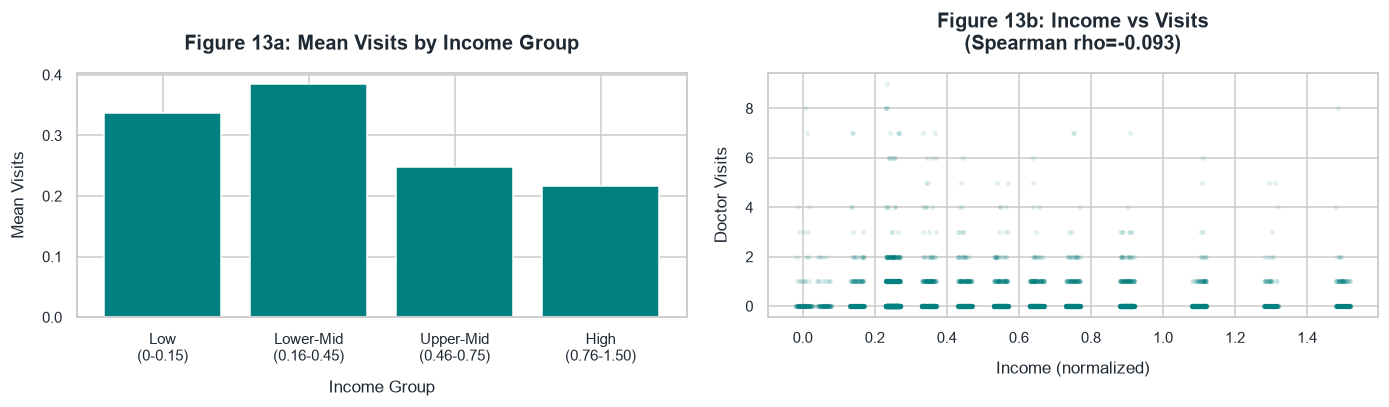

In [21]:
rho_i, p_i = stats.spearmanr(df['income'], df['visits'])
spearman_inc = pd.DataFrame({
    'Test': ['Spearman Correlation'],
    'Variables': ['income vs visits'],
    'rho': [f'{rho_i:.4f}'],
    'p-value': [f'{p_i:.2e}'],
    'Strength': ['Very weak negative association (income=0 rows ambiguous)']
}).set_index('Test')
display_table(spearman_inc, caption='Income correlation')

ig_order = ['Low(0-0.15)', 'Lower-Mid(0.16-0.45)', 'Upper-Mid(0.46-0.75)', 'High(0.76-1.50)']
ig = df.groupby('income_group')['visits'].agg(count='count', mean='mean').reindex(ig_order).round(4)
ig.columns = ['Count', 'Mean Visits']
ig.index.name = 'Income Group'
display_table(ig, caption='Visits by income group')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ig_labels = ['Low\n(0-0.15)', 'Lower-Mid\n(0.16-0.45)', 'Upper-Mid\n(0.46-0.75)', 'High\n(0.76-1.50)']
axes[0].bar(ig_labels, ig['Mean Visits'], color='teal', edgecolor='white')
axes[0].set_title('Figure 13a: Mean Visits by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Mean Visits')

# Scatter
jitter = np.random.RandomState(0).uniform(-0.02, 0.02, len(df))
axes[1].scatter(df['income'] + jitter, df['visits'], alpha=0.08, s=6, color='teal')
axes[1].set_title(f'Figure 13b: Income vs Visits\n(Spearman rho={rho_i:.3f})')
axes[1].set_xlabel('Income (normalized)')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig13_income_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Income has a very weak negative association with visits in the displayed Spearman result (rho = -0.0928). Lower income groups also show higher displayed means than the High group, but the effect is small and income=0 records are ambiguous.

### Q10. Are there differences in visit frequency by gender?

We compare mean visits between female and male respondents using
descriptive statistics and a Mann-Whitney U test.

,Count,Mean Visits,Median,Std Dev
Gender,,,,
female,"2,702",0.3620,0.0000,0.8579
male,"2,488",0.2363,0.0000,0.7222


,Comparison,U Statistic,p-value,Note
Test,,,,
Mann-Whitney U,Female vs Male visits,3655194,6.34e-15,Two-sided; binary gender only in dataset


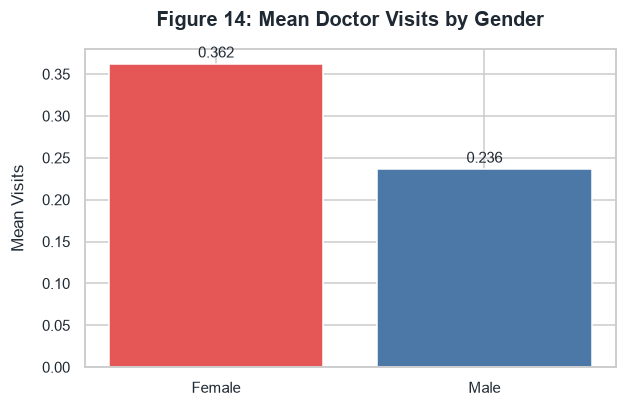

In [22]:
gd = df.groupby('gender')['visits'].agg(
    count='count', mean='mean', median='median', std='std'
).round(4)
gd.columns = ['Count', 'Mean Visits', 'Median', 'Std Dev']
gd.index.name = 'Gender'
display_table(gd, caption='Visits by gender')

female_v = df[df['gender']=='female']['visits']
male_v   = df[df['gender']=='male']['visits']
mw_stat, mw_p = stats.mannwhitneyu(female_v, male_v, alternative='two-sided')
mw_gender = pd.DataFrame({
    'Test': ['Mann-Whitney U'],
    'Comparison': ['Female vs Male visits'],
    'U Statistic': [f'{mw_stat:.0f}'],
    'p-value': [f'{mw_p:.2e}'],
    'Note': ['Two-sided; binary gender only in dataset']
}).set_index('Test')
display_table(mw_gender, caption='Gender comparison statistical test')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Female', 'Male'], [female_v.mean(), male_v.mean()],
              color=['#e45756', '#4c78a8'], edgecolor='white')
ax.set_title('Figure 14: Mean Doctor Visits by Gender')
ax.set_ylabel('Mean Visits')
for bar, val in zip(bars, [female_v.mean(), male_v.mean()]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig14_gender_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> Female respondents have a higher displayed mean visit count than male respondents, 0.3620 versus 0.2363, with a statistically significant Mann-Whitney result. The dataset contains binary gender categories only, so this comparison is limited to the recorded groups.

### Q11. What characterizes zero-visit vs. high-utilizer respondents?

We define:
- **Zero-visit group**: respondents with `visits == 0` (n=4,141, 79.8%)
- **High-utilizer group**: respondents with `visits >= 3` (n=93, 1.8%)

We compare their mean values on key health and demographic variables.

,n,Pct of Total
Group,,
Zero-visit (visits == 0),"4,141",79.8%
High-utilizer (visits >= 3),93,1.8%


,Zero-Visit Mean,High-Utilizer Mean,Difference (High − Zero)
Variable,,,
age_years,39.0340,46.9780,7.9440
income,0.5980,0.4960,-0.1020
illness,1.2560,2.4190,1.1630
reduced,0.4260,7.7530,7.3270
health,1.0220,3.0650,2.0430
private_enc,0.4440,0.3760,-0.0680
freepoor_enc,0.0490,0.0320,-0.0170
freerepat_enc,0.1800,0.2800,0.1000
nchronic_enc,0.3860,0.4520,0.0660


,Zero-Visit Mean,High-Utilizer Mean,Difference (High − Zero)
Variable,,,
% Female,49.3%,55.9%,—


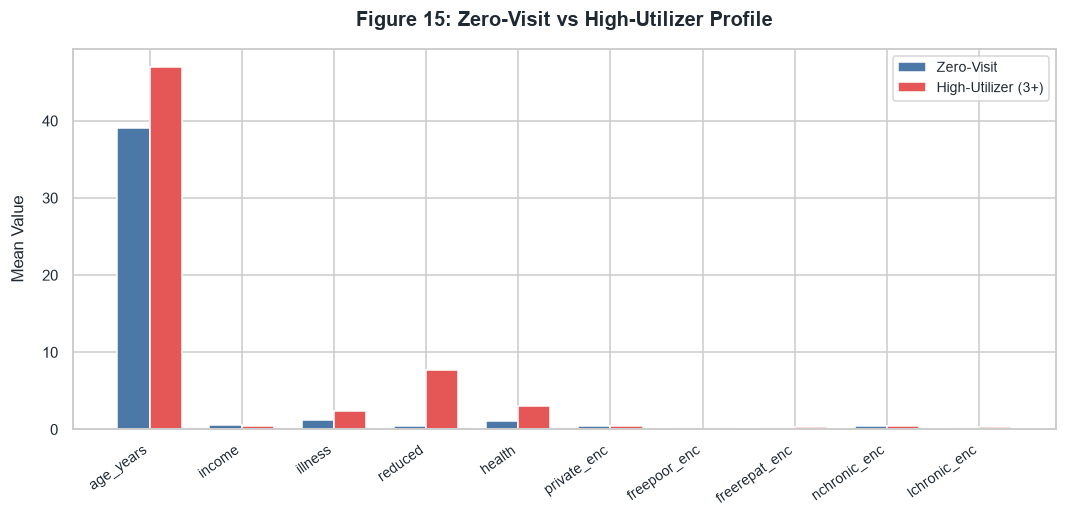

In [23]:
zero_grp = df[df['visits'] == 0]
high_grp = df[df['visits'] >= 3]

group_sizes = pd.DataFrame({
    'Group': ['Zero-visit (visits == 0)', 'High-utilizer (visits >= 3)'],
    'n': [len(zero_grp), len(high_grp)],
    'Pct of Total': [f'{len(zero_grp)/len(df)*100:.1f}%', f'{len(high_grp)/len(df)*100:.1f}%']
}).set_index('Group')
display_table(group_sizes, caption='Zero-visit and high-utilizer group sizes')

compare_cols = ['age_years', 'income', 'illness', 'reduced', 'health',
                'private_enc', 'freepoor_enc', 'freerepat_enc', 'nchronic_enc', 'lchronic_enc']

comp = pd.DataFrame({
    'Zero-Visit Mean': zero_grp[compare_cols].mean(),
    'High-Utilizer Mean': high_grp[compare_cols].mean(),
}).round(3)
comp['Difference (High − Zero)'] = (comp['High-Utilizer Mean'] - comp['Zero-Visit Mean']).round(3)
comp.index.name = 'Variable'
display_table(comp, caption='Zero-visit versus high-utilizer profile')

gender_row = pd.DataFrame({
    'Variable': ['% Female'],
    'Zero-Visit Mean': [f'{(zero_grp.gender=="female").mean()*100:.1f}%'],
    'High-Utilizer Mean': [f'{(high_grp.gender=="female").mean()*100:.1f}%'],
    'Difference (High − Zero)': ['—']
}).set_index('Variable')
display_table(gender_row, caption='Female representation by utilization group')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_cols))
width = 0.35
bars1 = ax.bar(x - width/2, comp['Zero-Visit Mean'], width, label='Zero-Visit', color='#4c78a8', edgecolor='white')
bars2 = ax.bar(x + width/2, comp['High-Utilizer Mean'], width, label='High-Utilizer (3+)', color='#e45756', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare_cols, rotation=35, ha='right', fontsize=9)
ax.set_title('Figure 15: Zero-Visit vs High-Utilizer Profile')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig15_zero_vs_high.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The high-utilizer group is small at 93 respondents, or 1.8% of the sample. Compared with the zero-visit group, it has higher displayed means for illness, reduced activity, health score, and limiting chronic-condition encoding; these are profile differences, not causal explanations.

### Q12. How is the health score associated with visit count?

The `health` column is a self-rated score (0–12). **The scale direction is unknown**
(higher may mean better or worse health). We report the association neutrally.

,Variables,rho,p-value,Note
Test,,,,
Spearman Correlation,health vs visits,0.1775,5.22e-38,Scale direction unknown — no directional medical interpretation made


,Count,Mean Visits
Health Score,,
0,"3,026",0.1993
1,823,0.3354
2,446,0.3812
3,273,0.4176
4,187,0.5348
5,132,0.5303
6,104,0.6250
7,61,0.9180
8,42,0.4762


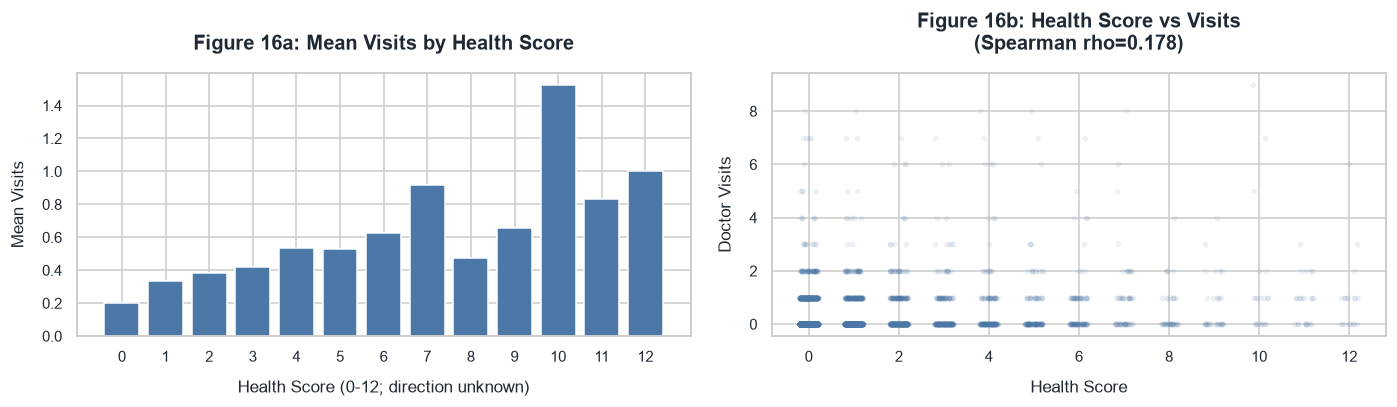

In [24]:
rho_h, p_h = stats.spearmanr(df['health'], df['visits'])
spearman_health = pd.DataFrame({
    'Test': ['Spearman Correlation'],
    'Variables': ['health vs visits'],
    'rho': [f'{rho_h:.4f}'],
    'p-value': [f'{p_h:.2e}'],
    'Note': ['Scale direction unknown — no directional medical interpretation made']
}).set_index('Test')
display_table(spearman_health, caption='Health-score correlation')

hs = df.groupby('health')['visits'].agg(count='count', mean='mean').round(4)
hs.columns = ['Count', 'Mean Visits']
hs.index.name = 'Health Score'
display_table(hs, caption='Visits by health score')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hs.index.astype(str), hs['Mean Visits'], color='#4c78a8', edgecolor='white')
axes[0].set_title('Figure 16a: Mean Visits by Health Score')
axes[0].set_xlabel('Health Score (0-12; direction unknown)')
axes[0].set_ylabel('Mean Visits')

jitter = np.random.RandomState(1).uniform(-0.2, 0.2, len(df))
axes[1].scatter(df['health'] + jitter, df['visits'], alpha=0.07, s=8, color='#4c78a8')
axes[1].set_title(f'Figure 16b: Health Score vs Visits\n(Spearman rho={rho_h:.3f})')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig16_health_visits.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The health score has a weak positive Spearman association with visits (rho = 0.1775). Because the score direction is undocumented, the result identifies an association with the recorded score only and should not be interpreted as better or worse health.

## 9. Correlation Analysis

Spearman rank correlation is used throughout this analysis because:
- `visits`, `illness`, `reduced`, and `health` are non-negative integer counts
- The dataset is heavily zero-inflated and right-skewed
- Spearman measures monotonic association without assuming normality

**Spearman correlation does not imply causation.**

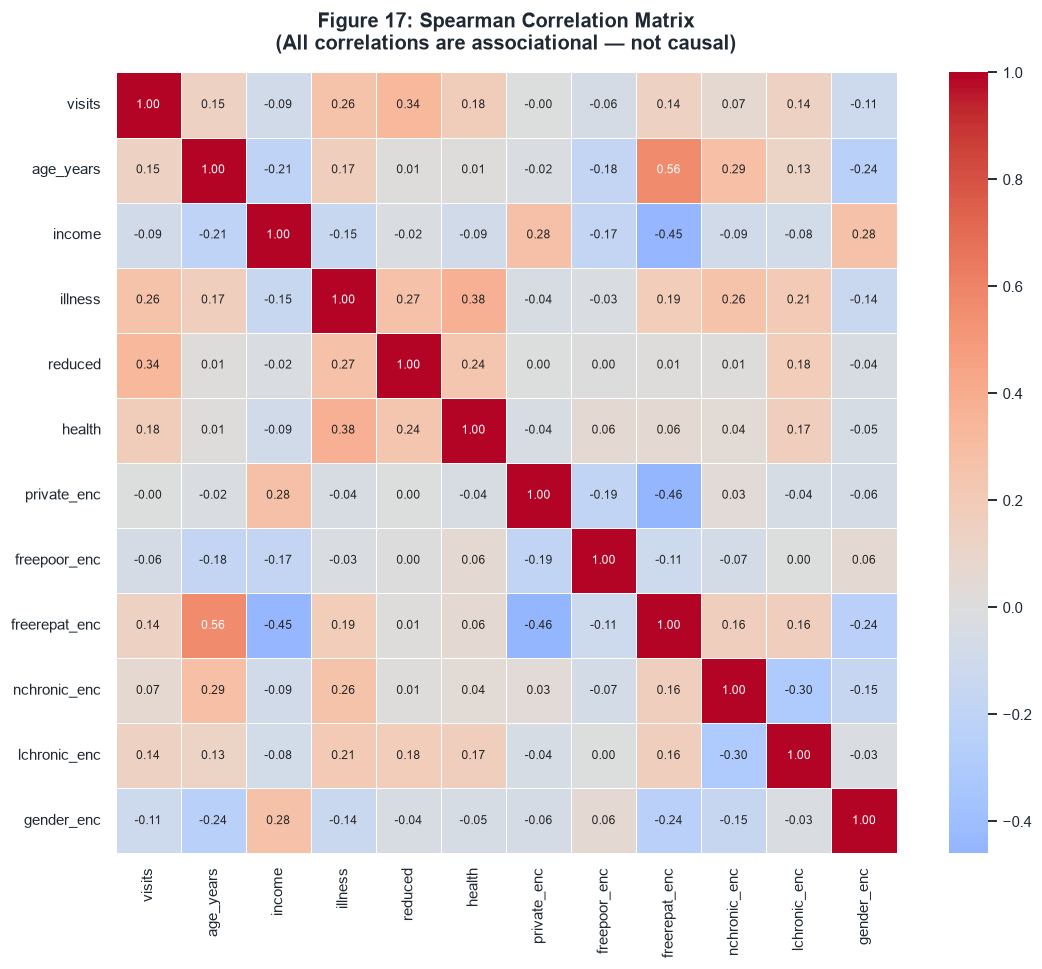

,Spearman rho with visits,Direction
Variable,,
reduced,0.3360,Positive
illness,0.2630,Positive
health,0.1780,Positive
age_years,0.1480,Positive
freerepat_enc,0.1450,Positive
lchronic_enc,0.1390,Positive
nchronic_enc,0.0690,Positive
private_enc,-0.0040,Negative
freepoor_enc,-0.0590,Negative


In [25]:
num_cols = ['visits', 'age_years', 'income', 'illness', 'reduced', 'health',
            'private_enc', 'freepoor_enc', 'freerepat_enc', 'nchronic_enc', 'lchronic_enc', 'gender_enc']

corr = df[num_cols].corr(method='spearman').round(3)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Figure 17: Spearman Correlation Matrix\n(All correlations are associational — not causal)')
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig17_correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

# Ranked correlation table with visits
visit_corr = corr['visits'].drop('visits').sort_values(ascending=False)
visit_corr_df = visit_corr.to_frame(name='Spearman rho with visits')
visit_corr_df.index.name = 'Variable'
visit_corr_df['Direction'] = visit_corr_df['Spearman rho with visits'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative'
)
display_table(visit_corr_df, caption='Variables ranked by Spearman association with visits')


### 💡 Key Insight

> Reduced activity has the strongest displayed Spearman association with visits (rho = 0.336), followed by illness (rho = 0.263) and health score (rho = 0.178). These rankings describe monotonic associations in this sample and do not establish causation.

## 10. Statistical Tests Summary

The following non-parametric tests were used because:
- `visits` is a count variable with extreme zero-inflation
- Normality assumptions cannot be satisfied
- Spearman correlation is appropriate for monotonic relationships in skewed data

| Test | Variables | Statistic | p-value | Interpretation |
|---|---|---|---|---|
| Spearman | reduced vs visits | rho=0.336 | <0.001 | Moderate positive association |
| Spearman | illness vs visits | rho=0.263 | <0.001 | Weak-moderate positive association |
| Spearman | health vs visits | rho=0.178 | <0.001 | Weak positive association |
| Spearman | age_years vs visits | rho=0.148 | <0.001 | Weak positive association |
| Spearman | income vs visits | rho=-0.093 | <0.001 | Very weak negative association |
| Kruskal-Wallis | chronic_status groups | H=170.6 | <0.001 | Groups differ significantly |
| Kruskal-Wallis | insurance_type groups | H=138.1 | <0.001 | Groups differ significantly |
| Kruskal-Wallis | illness count groups | H≈large | <0.001 | Groups differ significantly |
| Mann-Whitney U | govt-assisted vs private | U=1,625,202 | <0.001 | Statistically significant difference |
| Mann-Whitney U | female vs male | U=3,655,194 | <0.001 | Statistically significant difference |

**Important:** Statistical significance at p<0.05 in a dataset of 5,190 records is
easily achieved even for small effects. All p-values should be interpreted alongside
the practical effect size (rho, group mean difference). No test result implies causation.

### Visit Group Distribution Chart

,Count,Pct (%)
Visit Group,,
0 visits,"4,141",79.8%
1-2 visits,956,18.4%
3-5 visits,63,1.2%
6+ visits,30,0.6%


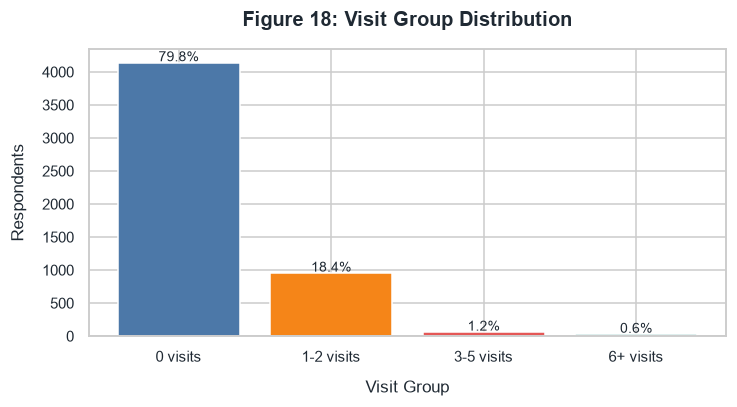

In [26]:
vg_order = ['0 visits', '1-2 visits', '3-5 visits', '6+ visits']
vg = df['visit_group'].value_counts().reindex(vg_order)
pct_vg = (vg / len(df) * 100).round(1)
vg_tbl = pd.DataFrame({'Count': vg, 'Pct (%)': pct_vg.map(lambda value: f'{value:.1f}%')})
vg_tbl.index.name = 'Visit Group'
display_table(vg_tbl, caption='Visit-group frequency table')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(vg.index, vg.values, color=['#4c78a8','#f58518','#e45756','#72b7b2'], edgecolor='white')
for bar, pct in zip(bars, pct_vg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct}%', ha='center', fontsize=9)
ax.set_title('Figure 18: Visit Group Distribution')
ax.set_xlabel('Visit Group')
ax.set_ylabel('Respondents')
plt.tight_layout(pad=1.5)
plt.savefig('../data/processed/fig18_visit_groups.png', dpi=110, bbox_inches='tight')
plt.show()


### 💡 Key Insight

> The visit-group table shows that 79.8% of respondents are in the 0-visits group, while 18.4% report 1–2 visits. The 3+ visit groups together represent a small minority of the sample.

## 11. Outliers and Data Limitations

This section documents important data characteristics that affect interpretation.

In [27]:
# IQR outlier check on visits
q1 = df['visits'].quantile(0.25)
q3 = df['visits'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outlier_summary = pd.DataFrame({
    'Check': [
        'visits Q1',
        'visits Q3',
        'visits IQR',
        'Upper fence (Q3 + 1.5×IQR)',
        'Rows above fence',
        'reduced=14 (censoring ceiling) rows',
        'income=0 (ambiguous) rows'
    ],
    'Value': [
        str(q1), str(q3), str(iqr), str(upper_fence),
        f'{(df.visits > upper_fence).sum()} (all non-zero; IQR removal inappropriate for zero-inflated data)',
        f'{df.reduced_at_ceiling.sum()} (NOT outliers — 14 = censored ceiling, 2-week maximum)',
        f'{df.income_zero_flag.sum()} (ambiguous — true zero or missing-value code; no imputation)'
    ]
}).set_index('Check')
display_table(outlier_summary, caption='Outlier and data-characteristic checks')


,Value
Check,
visits Q1,0.0
visits Q3,0.0
visits IQR,0.0
Upper fence (Q3 + 1.5×IQR),0.0
Rows above fence,1049 (all non-zero; IQR removal inappropriate for zero-inflated data)
reduced=14 (censoring ceiling) rows,"188 (NOT outliers — 14 = censored ceiling, 2-week maximum)"
income=0 (ambiguous) rows,79 (ambiguous — true zero or missing-value code; no imputation)


### 💡 Key Insight

> The IQR check flags all 1,049 non-zero visit records above a zero-based upper fence, illustrating why routine IQR removal would be inappropriate for this zero-inflated count outcome. The reduced=14 and income=0 cases are documented data characteristics rather than automatically removable outliers.

### Documented Limitations

| Limitation | Impact on Analysis |
|---|---|
| **Zero-inflated visits** | Group means are depressed; medians = 0 for almost all subgroups |
| **Right-skewed visits** | Mean is not representative of a typical respondent |
| **`reduced = 14` ceiling** | 188 rows have censored values; true activity loss may be larger |
| **`income = 0` ambiguity** | 79 rows — true zero income vs. missing code undetermined |
| **`health` scale direction** | Unknown — higher may mean better *or* worse health |
| **Self-reported variables** | `illness`, `health`, `reduced` are subjective; not clinically coded |
| **Binary gender only** | Non-binary identities unrepresented |
| **Discrete age bands** | Age is not continuous — 12 bands; cannot treat as fully continuous |
| **Dataset provenance** | Country, year, survey design not confirmed in the file |
| **Identical attribute rows** | 1,320 duplicated rows on original 12 cols — distinct respondents with shared profiles |
| **Small high-utilizer group** | n=93 for visits≥3; conclusions about this group are tentative |
| **No longitudinal data** | Snapshot in time; cannot track individuals over time |

## 12. Key Findings

> All findings below are **descriptive associations** calculated from the processed dataset.  
> They describe patterns in the sample. They do not establish causation,  
> diagnose conditions, or generalize to specific clinical populations.

---

### Visit Patterns

- **79.8% of respondents (4,141 of 5,190) reported zero doctor visits** in the reference period.
- The mean visit count is **0.302** and the maximum is **9**. The distribution is strongly right-skewed (skewness ≈ 4).
- Only 93 respondents (1.8%) reported 3 or more visits — the high-utilizer group.
- The dataset is zero-inflated: standard regression and correlation methods must account for this structure.

---

### Demographic Patterns

- **Age**: Mean visit counts increase monotonically from the youngest (≤25: 0.206) to the oldest (66+: 0.454) age group.
- **Gender**: Female respondents show a higher mean visit count (0.362) compared to male (0.236). The Mann-Whitney test confirms a statistically significant difference (p<0.001). The practical effect is modest.
- The dataset contains only binary gender categories; non-binary representation is absent.

---

### Health Burden

- **Illness**: Respondents reporting any illness show a mean visit count of 0.397, compared to 0.079 for those reporting no illness. The relationship is monotonically increasing from illness=0 (mean=0.079) to illness=5 (mean=0.814).
- **Reduced activity**: Spearman rho=0.336 (p<0.001) — the strongest correlate with visits. Respondents with 8–14 reduced-activity days had a mean visit count of 1.641.
- **Chronic conditions**: Limiting chronic conditions (mean=0.603) are associated with higher visit counts than non-limiting (0.346) or no conditions (0.192). Kruskal-Wallis H=170.6 (p<0.001).
- **Health score**: Spearman rho=0.178 (p<0.001) — weak positive association. Scale direction unknown.

---

### Insurance and Income

- **Free-Repatriated** respondents show the highest mean visits (0.467), followed by **Private** (0.295), **Uninsured** (0.219), and **Free-Poor** (0.158).
- The government-assisted pool (Free-Poor + Free-Repatriated) shows higher mean visits (0.414) than the private group (0.295). Mann-Whitney p<0.001.
- **Income**: Spearman rho=-0.093 — a very weak negative association. Lower income tiers show slightly higher mean visits. Practical effect size is small.
- The three insurance variables are perfectly mutually exclusive (no overlap in the entire dataset).

---

### Relationships and Correlations

| Variable | Spearman rho with visits | Direction |
|---|---|---|
| `reduced` | 0.336 | Positive |
| `illness` | 0.263 | Positive |
| `health` | 0.178 | Positive (direction of scale unknown) |
| `age_years` | 0.148 | Positive |
| `freerepat_enc` | 0.145 | Positive |
| `lchronic_enc` | 0.139 | Positive |
| `nchronic_enc` | 0.069 | Positive |
| `gender_enc` (male) | -0.108 | Negative |
| `income` | -0.093 | Negative |
| `freepoor_enc` | -0.059 | Negative |

---

### Data Limitations

- The `health` scale direction is undocumented; health-related findings are reported without directional interpretation.
- 79 income=0 rows are ambiguous (true zero vs. missing code).
- 188 `reduced=14` rows represent censored values.
- The high-utilizer group (n=93) is small; conclusions about extreme utilizers are tentative.
- All results are cross-sectional and observational.

### 💡 Key Insight

> The combined findings should be read as descriptive patterns in a cross-sectional survey. Zero inflation, self-reported variables, censored reduced-activity values, ambiguous income=0 records, undocumented health-score direction, and limited provenance all constrain interpretation and generalization.

## 13. Conclusion

This notebook has performed a complete exploratory data analysis of the Healthcare Doctor Visits
survey dataset. The analysis identified a number of **descriptive associations** between doctor
visit frequency and health, demographic, insurance, and income variables.

**Key takeaway:** The strongest observable associations with visit frequency involve direct
health-burden indicators — reduced-activity days (rho=0.336), illness count (rho=0.263),
and chronic condition severity — rather than demographic or socioeconomic variables alone.

**What this analysis does NOT do:**
- It does not establish causal relationships between any variables.
- It does not diagnose or classify health conditions.
- It does not generalize findings to any specific clinical population.
- It does not make policy recommendations.

**Next steps (Phase 4 and beyond):**
- Interactive Streamlit dashboard for dynamic exploration
- Premium HTML/CSS/JS dashboard for portfolio presentation
- GitHub-ready packaging with a professional README

---

*Project: Healthcare Analytics for Doctor Visits — Phase 3 EDA Complete*

### 💡 Key Insight

> The notebook consistently points to health-burden indicators, especially reduced activity and illness, as the strongest observed associations with visit frequency. This remains an exploratory summary: the analysis does not establish causation, diagnose conditions, or generalize to a specific clinical population.